In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/sms-spam-collection-dataset/spam.csv


In [37]:
import pandas as pd

In [38]:
path = '/kaggle/input/datasets/uciml/sms-spam-collection-dataset/spam.csv'
df = pd.read_csv(path, encoding='latin-1')

In [39]:
print(df.head(5))

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [40]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [41]:
df['v1']

0        ham
1        ham
2       spam
3        ham
4        ham
        ... 
5567    spam
5568     ham
5569     ham
5570     ham
5571     ham
Name: v1, Length: 5572, dtype: object

In [42]:
print(df['v2'])

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: v2, Length: 5572, dtype: object


In [43]:
train = pd.DataFrame(df[['v1' , 'v2']])

In [44]:
train = train.rename(columns = {'v1' : 'target' , 'v2' :'information'})

In [45]:
print(train)

     target                                        information
0       ham  Go until jurong point, crazy.. Available only ...
1       ham                      Ok lar... Joking wif u oni...
2      spam  Free entry in 2 a wkly comp to win FA Cup fina...
3       ham  U dun say so early hor... U c already then say...
4       ham  Nah I don't think he goes to usf, he lives aro...
...     ...                                                ...
5567   spam  This is the 2nd time we have tried 2 contact u...
5568    ham              Will Ì_ b going to esplanade fr home?
5569    ham  Pity, * was in mood for that. So...any other s...
5570    ham  The guy did some bitching but I acted like i'd...
5571    ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [46]:
train.isnull().sum()

target         0
information    0
dtype: int64

In [51]:
train['information'] = train['information'].str.lower()
train

,target,information
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,this is the 2nd time we have tried 2 contact u...
5568,ham,will ì_ b going to esplanade fr home?
5569,ham,"pity, * was in mood for that. so...any other s..."
5570,ham,the guy did some bitching but i acted like i'd...


In [54]:
train['information'] = train['information'].str.replace(r'[^a-zA-Z\s]', '', regex=True)
train['information'] = train['information'].str.strip().str.replace(r'\s+', ' ', regex=True)

In [55]:
print(train)

     target                                        information
0       ham  go until jurong point crazy available only in ...
1       ham                            ok lar joking wif u oni
2      spam  free entry in a wkly comp to win fa cup final ...
3       ham        u dun say so early hor u c already then say
4       ham  nah i dont think he goes to usf he lives aroun...
...     ...                                                ...
5567   spam  this is the nd time we have tried contact u u ...
5568    ham                  will b going to esplanade fr home
5569    ham  pity was in mood for that soany other suggestions
5570    ham  the guy did some bitching but i acted like id ...
5571    ham                          rofl its true to its name

[5572 rows x 2 columns]


In [58]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [60]:
def lemmatize(text):
    doc = nlp(str(text))
    return " ".join([token.lemma_ for token in doc])

In [62]:
train['information'] = train['information'].apply(lemmatize)

In [64]:
train.drop_duplicates()

,target,information
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final ...
3,ham,u dun say so early hor u c already then say
4,ham,nah I do not think he go to usf he live around...
...,...,...
5567,spam,this be the nd time we have try contact u u ha...
5568,ham,will b go to esplanade fr home
5569,ham,pity be in mood for that soany other suggestion
5570,ham,the guy do some bitching but I act like I d be...


In [65]:
def remove_stopwords(text):
    doc = nlp(str(text))
    return " ".join([token.lemma_ for token in doc if not token.is_stop])

In [67]:
train['information'] = train['information'].apply(remove_stopwords)

In [68]:
print(train)

     target                                        information
0       ham  jurong point crazy available bugis n great wor...
1       ham                            ok lar joking wif u oni
2      spam  free entry wkly comp win fa cup final tkts st ...
3       ham                                u dun early hor u c
4       ham                                 nah think usf live
...     ...                                                ...
5567   spam  nd time try contact u u win pound prize claim ...
5568    ham                                b esplanade fr home
5569    ham                         pity mood soany suggestion
5570    ham   guy bitching act like d interested buy week free
5571    ham                                          rofl true

[5572 rows x 2 columns]


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


model = MultinomialNB()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)


print( accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))



0.9748878923766816
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       0.99      0.82      0.90       150

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



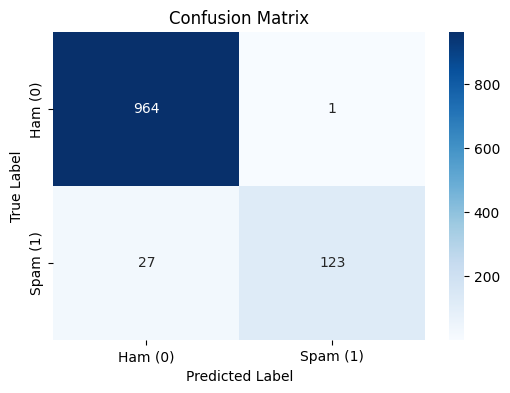

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)


plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham (0)', 'Spam (1)'], 
            yticklabels=['Ham (0)', 'Spam (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


0.967713004484305


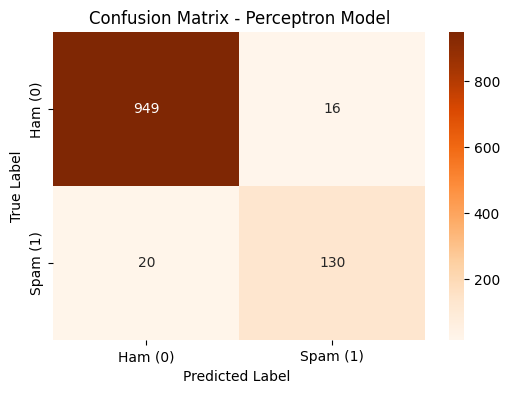

In [74]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

perceptron_model = Perceptron(max_iter=100, random_state=42)

perceptron_model.fit(X_train, Y_train)

Y_pred_perc = perceptron_model.predict(X_test)

print(accuracy_score(Y_test, Y_pred_perc))
cm_perc = confusion_matrix(Y_test, Y_pred_perc)

plt.figure(figsize=(6,4))
sns.heatmap(cm_perc, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Ham (0)', 'Spam (1)'], 
            yticklabels=['Ham (0)', 'Spam (1)'])

plt.xlabel('Predicted Label ')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Perceptron Model')
plt.show()
